In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install torch torchvision pillow matplotlib tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import random

In [ ]:
CLASSES = ['_background_', 'Road', 'Excavated', 'Land', 'Cement']
COLOR_PALETTE = torch.tensor([
    [0, 0, 0],        # Background
    [27, 122, 0],     # Road
    [162, 115, 83],   # Excavated
    [110, 67, 38],    # Land
    [176, 176, 176]   # Cement
])

In [ ]:
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, transform=None, img_size=256):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.img_size = img_size
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name.split('.')[0] + '.png')

        # Load image and mask
        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path).convert('L')  # Convert to grayscale

        # Resize both image and mask to the same size
        image = image.resize((self.img_size, self.img_size), Image.BILINEAR)
        mask = mask.resize((self.img_size, self.img_size), Image.NEAREST)  # Use NEAREST for masks to preserve labels

        # Apply transformations to image
        if self.transform:
            image = self.transform(image)

        # Convert mask to tensor
        mask = torch.from_numpy(np.array(mask))

        return image, mask

In [ ]:
class SegmentationTransform:
    def __init__(self, img_size=256):
        self.img_size = img_size

    def __call__(self, image):
        # Convert to tensor and normalize
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        return image

In [ ]:
class SegmentationTransform:
    def __init__(self, img_size=256):
        self.img_size = img_size

    def __call__(self, image):
        # Convert to tensor and normalize
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        image = TF.resize(image, (self.img_size, self.img_size))
        return image

In [ ]:
class UNet(nn.Module):
    def __init__(self, n_classes):
        super(UNet, self).__init__()

        # Encoder
        self.enc1 = self._block(3, 64)
        self.enc2 = self._block(64, 128)
        self.enc3 = self._block(128, 256)
        self.enc4 = self._block(256, 512)

        # Bottleneck
        self.bottleneck = self._block(512, 1024)

        # Decoder
        self.dec4 = self._block(1024 + 512, 512)
        self.dec3 = self._block(512 + 256, 256)
        self.dec2 = self._block(256 + 128, 128)
        self.dec1 = self._block(128 + 64, 64)

        # Final layer
        self.final = nn.Conv2d(64, n_classes, kernel_size=1)

        self.pool = nn.MaxPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

    def _block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder
        d4 = self.dec4(torch.cat([self.upsample(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.upsample(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.upsample(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.upsample(d2), e1], dim=1))

        return self.final(d1)

In [ ]:
def train_model(model, train_loader, criterion, optimizer, device, num_epochs=50):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        running_loss = 0.0

        for batch_idx, (images, masks) in enumerate(tqdm(train_loader)):
            images = images.to(device)
            masks = masks.to(device)

            # Print shapes for debugging
            if batch_idx == 0:
                print(f"Image shape: {images.shape}")
                print(f"Mask shape: {masks.shape}")

            optimizer.zero_grad()
            outputs = model(images)

            # Print output shape for debugging
            if batch_idx == 0:
                print(f"Output shape: {outputs.shape}")

            loss = criterion(outputs, masks.long())
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

    return train_losses

In [ ]:
def predict_and_visualize(model, image_path, device):
    model.eval()
    transform = SegmentationTransform()

    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        pred_mask = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    # Create color mask
    color_mask = np.zeros((pred_mask.shape[0], pred_mask.shape[1], 3), dtype=np.uint8)
    for i, color in enumerate(COLOR_PALETTE):
        color_mask[pred_mask == i] = color

    # Visualization
    plt.figure(figsize=(12, 4))
    plt.subplot(131)
    plt.imshow(image)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(132)
    plt.imshow(pred_mask)
    plt.title('Segmentation Mask')
    plt.axis('off')

    plt.subplot(133)
    plt.imshow(color_mask)
    plt.title('Colored Segmentation')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

Using device: cuda
Dataset size: 52
First image shape: torch.Size([3, 256, 256])
First mask shape: torch.Size([256, 256])


  0%|          | 0/11 [00:00<?, ?it/s]

Image shape: torch.Size([4, 3, 256, 256])
Mask shape: torch.Size([4, 256, 256])
Output shape: torch.Size([4, 5, 256, 256])


100%|██████████| 11/11 [00:31<00:00,  2.88s/it]


Epoch 1/50, Loss: 0.9530


...

Epoch 49/50, Loss: 0.0851


  0%|          | 0/11 [00:00<?, ?it/s]

Image shape: torch.Size([4, 3, 256, 256])
Mask shape: torch.Size([4, 256, 256])
Output shape: torch.Size([4, 5, 256, 256])


100%|██████████| 11/11 [00:04<00:00,  2.32it/s]


Epoch 50/50, Loss: 0.1066


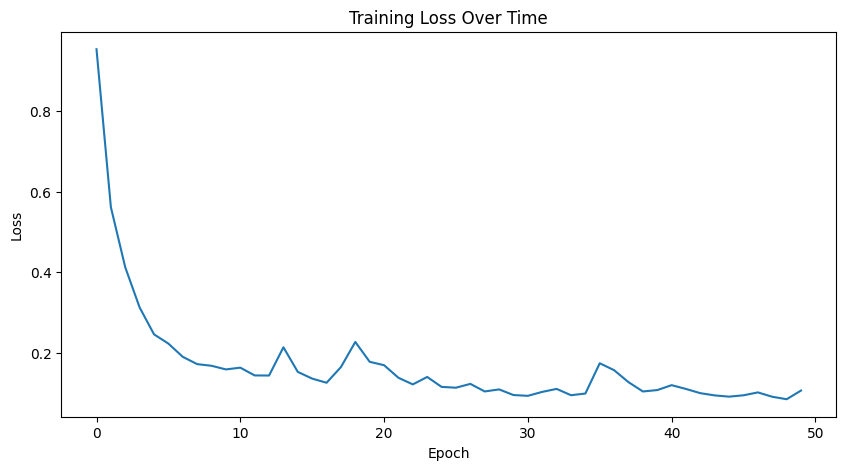

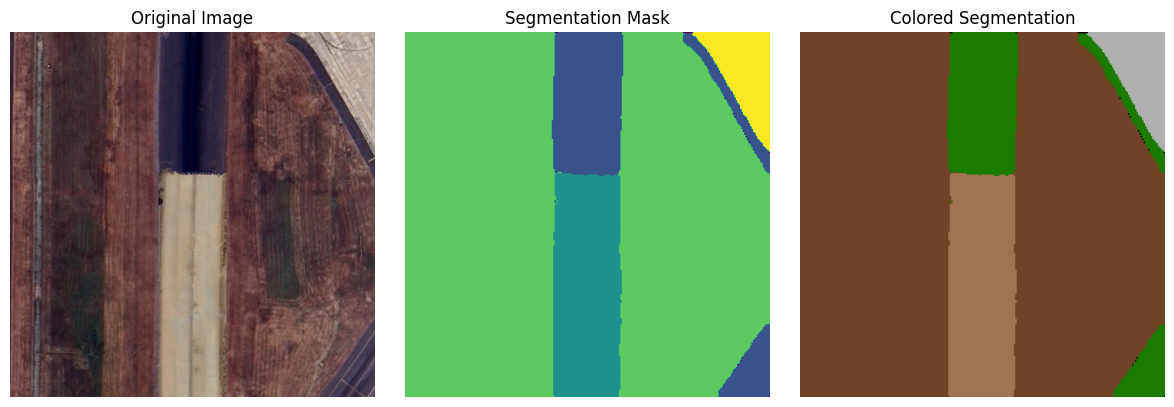

In [ ]:
def main():
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Dataset and DataLoader with fixed size
    IMG_SIZE = 256
    transform = SegmentationTransform()
    dataset = SegmentationDataset(
        img_dir='/content/drive/MyDrive/road_dataset/dataset/images',
        mask_dir='/content/drive/MyDrive/road_dataset/dataset/segmentation_class',
        transform=transform
    )

    # Print dataset size
    print(f"Dataset size: {len(dataset)}")

    # Check first item shapes
    first_image, first_mask = dataset[0]
    print(f"First image shape: {first_image.shape}")
    print(f"First mask shape: {first_mask.shape}")

    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

    # Initialize model
    model = UNet(n_classes=len(CLASSES)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Train model
    losses = train_model(model, train_loader, criterion, optimizer, device)

    # Plot training losses
    plt.figure(figsize=(10, 5))
    plt.plot(losses)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

    # Save model
    torch.save(model.state_dict(), 'unet_model.pth')

    predict_and_visualize(model, '/content/drive/MyDrive/road_dataset/dataset/images/1732963292137.jpg', device)

if __name__ == '__main__':
    main()